<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.5 MB/s eta 0:00:00


### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [2]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

--2026-07-16 23:42:52--  http://songs_dataset.zip/
Resolving songs_dataset.zip (songs_dataset.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘songs_dataset.zip’
--2026-07-16 23:42:52--  https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip [following]
--2026-07-16 23:42:53--  https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (ra

In [3]:
# Posibles bandas
os.listdir("./songs_dataset/")

['patti-smith.txt',
 'disney.txt',
 'beatles.txt',
 'bjork.txt',
 'bob-dylan.txt',
 'dolly-parton.txt',
 'lorde.txt',
 'eminem.txt',
 'rihanna.txt',
 'al-green.txt',
 'drake.txt',
 'adele.txt',
 'blink-182.txt',
 'missy-elliott.txt',
 'lady-gaga.txt',
 'nickelback.txt',
 'britney-spears.txt',
 'Kanye_West.txt',
 'lil-wayne.txt',
 'radiohead.txt',
 'michael-jackson.txt',
 'johnny-cash.txt',
 'notorious_big.txt',
 'kanye-west.txt',
 'nirvana.txt',
 'lin-manuel-miranda.txt',
 'bob-marley.txt',
 'bruno-mars.txt',
 'paul-simon.txt',
 'dj-khaled.txt',
 'r-kelly.txt',
 'kanye.txt',
 'janisjoplin.txt',
 'nicki-minaj.txt',
 'leonard-cohen.txt',
 'bieber.txt',
 'ludacris.txt',
 'joni-mitchell.txt',
 'Lil_Wayne.txt',
 'dr-seuss.txt',
 'dickinson.txt',
 'alicia-keys.txt',
 'cake.txt',
 'bruce-springsteen.txt',
 'jimi-hendrix.txt',
 'prince.txt',
 'amy-winehouse.txt',
 'notorious-big.txt',
 'nursery_rhymes.txt']

In [4]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_2738/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [5]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [6]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [7]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [8]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [9]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [10]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [11]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [12]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [13]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.984375
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.65625
Loss after epoch 6: 64080.21875
Loss after epoch 7: 64814.875
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58884.375
Loss after epoch 12: 57715.75
Loss after epoch 13: 56494.3125
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.4375
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.25
Loss after epoch 19: 48960.125


(156986, 287740)

### 4 - Ensayar

In [14]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954247832298279),
 ('sleep', 0.8665655851364136),
 ('help', 0.8439376354217529),
 ('cry', 0.8351269960403442),
 ('not', 0.8309612274169922),
 ('try', 0.8276943564414978),
 ('peace', 0.8144856691360474),
 ('little', 0.8140572309494019),
 ('twist', 0.8123919367790222),
 ('seems', 0.8079564571380615)]

In [15]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873197495937347),
 ('four', -0.2330218255519867),
 ('five', -0.23746445775032043),
 ('six', -0.23784494400024414),
 ('bang', -0.24832050502300262),
 ('our', -0.25539135932922363),
 ('day', -0.2689811885356903),
 ('going', -0.2692062556743622),
 ('here', -0.26990723609924316),
 ('three', -0.2838989198207855)]

In [16]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813723564147949),
 ('three', 0.9745770692825317),
 ('six', 0.9710808992385864),
 ('seven', 0.9584357738494873),
 ('two', 0.9517216682434082),
 ('sixty', 0.8990395665168762),
 ('one', 0.7951181530952454),
 ('crying', 0.7946289777755737),
 ('us', 0.7740051746368408),
 ("i'm", 0.7508383393287659)]

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434017539024353),
 ('buy', 0.9396998882293701),
 ('much', 0.9033146500587463),
 ('just', 0.8509082198143005),
 ('hide', 0.835538387298584)]

In [18]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

KeyError: "Key 'diedaa' not present in vocabulary"

In [19]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138203  0.05881222 -0.06370417  0.02444947 -0.20152196 -0.18612292
 -0.15284595  0.4548753  -0.04217871  0.03536078  0.13657516 -0.18520005
 -0.1812647   0.22149836 -0.3038084  -0.23970386  0.07094695 -0.05679139
 -0.05166207 -0.23843557 -0.08530281  0.19564727 -0.07678778  0.03797247
  0.07517307 -0.04826551  0.07379535  0.10396848  0.00738022 -0.22764729
 -0.0456724   0.12937619  0.27785638  0.19387618 -0.13509148  0.20857106
  0.40917322 -0.00387122 -0.1063128  -0.09056759  0.02400028 -0.0800491
  0.13400665  0.08833536 -0.01894405  0.08592905 -0.15905626  0.10259357
  0.14459287 -0.12092585 -0.27919102 -0.04061577  0.11382084  0.31365854
 -0.07409792  0.13976744  0.22791271  0.13209458 -0.01811365  0.09772275
  0.09249583 -0.14871688 -0.16348091 -0.13203284 -0.09834065  0.02714608
  0.16531324  0.26051944 -0.0325964  -0.02894551  0.11621328 -0.06974234
  0.09563565 -0.15276384  0.22071053  0.15996666  0.1589048  -0.04711676
 -0.12555045 -0.03993924 -0.10795183  0.01878959  0.

In [20]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638361096382141),
 ("there's", 0.8526672720909119),
 ('you', 0.8456704616546631),
 ('feed', 0.8445017337799072),
 ('somebody', 0.8362804651260376)]

In [21]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638360500335693),
 ("there's", 0.8526672720909119),
 ('you', 0.8456703424453735),
 ('feed', 0.8445016741752625),
 ('somebody', 0.8362804651260376),
 ('buy', 0.8351694941520691)]

### 5 - Visualizar agrupación de vectores

In [22]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [23]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [24]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [25]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

**Elección del corpus:** para este desafío se usó el corpus de la banda **Iron Maiden**, en lugar del de Beatles. Se eligió este artista porque es de mis bandas favoritas, ademas de contar con muchisimas canciones. Su vocabulario es rico y temáticamente variado.

In [26]:
#Descargamos de Kaggle
import kagglehub

path = kagglehub.dataset_download("gabrieldu69/iron-maiden-songs")
print(path)

import os
print(os.listdir(path))

100%|██████████| 37.5k/37.5k [00:00<00:00, 2.57MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/gabrieldu69/iron-maiden-songs/versions/2
['iron-maiden-songs.txt']


In [27]:
#Abrimos el archivo descargado:
with open(f"{path}/iron-maiden-songs.txt", encoding="utf-8", errors="replace") as f:
    lineas = f.readlines()

print("Total de líneas:", len(lineas))
for l in lineas[:20]:
    print(repr(l))

Total de líneas: 4873
'Title :  Prowler \n'
'\n'
'\n'
'\n'
'Walking through the city\n'
'Looking oh-so pretty\n'
"I've just got to find my way\n"
'See the ladies flashing\n'
'All their legs and lashes\n'
"I've just got to find my way\n"
'\n'
'Well... you see me crawling through the bushes\n'
'With it open wide\n'
'What you seeing, girl?\n'
"Can't you believe that feeling, can't you believe it\n"
"Can't you believe your eyes?\n"
"It's the real thing, girl!\n"
'\n'
'Got me feeling myself and reeling around\n'
'Got me talking but feel like walking around\n'


In [28]:
# Vemos que no esta depurado el corpus. Contiene saltos de linea y titulos de canciones.
# Vamos a quitarlos:

import re
versos = []
titulo_actual = None
canciones = {}

for linea in lineas:
    linea = linea.strip()
    if not linea:
        continue
    m = re.match(r'^Title\s*:\s*(.+)$', linea, re.IGNORECASE)
    if m:
        titulo_actual = m.group(1).strip()
        canciones[titulo_actual] = []
        continue
    versos.append(linea)
    if titulo_actual:
        canciones[titulo_actual].append(linea)

print("Cantidad de versos:", len(versos))
print("Cantidad de canciones detectadas:", len(canciones))
print("Primeras canciones:", list(canciones.keys())[:10])

Cantidad de versos: 3749
Cantidad de canciones detectadas: 98
Primeras canciones: ['Prowler', 'Sanctuary', 'Remember Tomorrow', 'Running Free', 'Phantom Of The Opera', 'Strange World', 'Charlotte The Harlot', 'Iron Maiden', 'Wrathchild', 'Murders In The Rue Morgue']


In [29]:
# canciones es un diccionario que tiene el titulo de la cancion y la letra
print(canciones["Running Free"][:6])

['Just sixteen, a pickup truck', 'Out of money, out of luck', "I've got nowhere to call my own", 'Hit the gas, and here I go', "I'm running free, yeah", "I'm running free"]


In [30]:
# versos es una lista que tiene los versos de todas las canciones
print(versos[:6])

['Walking through the city', 'Looking oh-so pretty', "I've just got to find my way", 'See the ladies flashing', 'All their legs and lashes', "I've just got to find my way"]


In [31]:
import pandas as pd
df=pd.DataFrame(versos)

In [32]:
df

,0
0,Walking through the city
1,Looking oh-so pretty
2,I've just got to find my way
3,See the ladies flashing
4,All their legs and lashes
...,...
3744,Maybe lightning strikes twice
3745,Maybe lightning strikes twice
3746,Maybe lightning strikes twice
3747,Maybe lightning strikes twice


In [33]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [34]:
# Demos un vistazo
sentence_tokens[:6]

[['walking', 'through', 'the', 'city'],
 ['looking', 'oh', 'so', 'pretty'],
 ["i've", 'just', 'got', 'to', 'find', 'my', 'way'],
 ['see', 'the', 'ladies', 'flashing'],
 ['all', 'their', 'legs', 'and', 'lashes'],
 ["i've", 'just', 'got', 'to', 'find', 'my', 'way']]

In [35]:
print("Cantidad de oraciones tokenizadas:", len(sentence_tokens))

Cantidad de oraciones tokenizadas: 3749


In [36]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [37]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=3,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=4,       # cant de palabras antes y desp de la predicha
                     vector_size=100,       # dimensionalidad de los vectores
                     negative=10,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [38]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [39]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 3749


In [40]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 1027


In [41]:
# Entrenamos el modelo generador de vectores
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=50,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 229991.125
Loss after epoch 1: 150826.28125
Loss after epoch 2: 145130.34375
Loss after epoch 3: 141085.75
Loss after epoch 4: 136894.5625
Loss after epoch 5: 133688.9375
Loss after epoch 6: 128898.125
Loss after epoch 7: 125257.625
Loss after epoch 8: 119671.75
Loss after epoch 9: 116400.0
Loss after epoch 10: 112933.25
Loss after epoch 11: 109553.25
Loss after epoch 12: 106140.75
Loss after epoch 13: 103453.5
Loss after epoch 14: 101394.125
Loss after epoch 15: 97407.375
Loss after epoch 16: 93275.5
Loss after epoch 17: 87158.75
Loss after epoch 18: 86179.25
Loss after epoch 19: 85470.75
Loss after epoch 20: 83532.25
Loss after epoch 21: 83373.0
Loss after epoch 22: 81108.25
Loss after epoch 23: 82410.25
Loss after epoch 24: 80089.75
Loss after epoch 25: 79739.75
Loss after epoch 26: 78673.75
Loss after epoch 27: 78174.75
Loss after epoch 28: 78638.75
Loss after epoch 29: 77790.0
Loss after epoch 30: 77550.25
Loss after epoch 31: 76480.75
Loss after epoch 32: 7554

(783711, 1221550)

La loss decrece de forma consistente a lo largo de las épocas, lo cual indica que el modelo efectivamente está aprendiendo representaciones que ayudan a predecir el contexto de cada palabra

In [42]:
palabras_candidatas = ["beast", "maiden", "war", "world", "king", "cocoliso"]

for palabra in palabras_candidatas:
    if palabra in w2v_model.wv.index_to_key:
        print(f"=== {palabra} ===")

        print("  -- Más cercanas --")
        for w, score in w2v_model.wv.most_similar(positive=[palabra], topn=3):
            print(f"    {w}: {score:.3f}")

        print("  -- Más alejadas --")
        for w, score in w2v_model.wv.most_similar(negative=[palabra], topn=3):
            print(f"    {w}: {score:.3f}")

        print()
    else:
        print(f"'{palabra}' no está en el vocabulario\n")

=== beast ===
  -- Más cercanas --
    666: 0.685
    she'd: 0.640
    seen: 0.622
  -- Más alejadas --
    ready: 0.008
    begins: 0.007
    lives: -0.002

=== maiden ===
  -- Más cercanas --
    iron: 0.926
    sought: 0.902
    fought: 0.792
  -- Más alejadas --
    golden: -0.061
    black: -0.070
    nightmare: -0.085

=== war ===
  -- Más cercanas --
    fortunes: 0.770
    freedom's: 0.716
    stain: 0.677
  -- Más alejadas --
    walking: 0.039
    an: -0.007
    goes: -0.014

=== world ===
  -- Más cercanas --
    mend: 0.671
    brave: 0.647
    holding: 0.630
  -- Más alejadas --
    they: 0.014
    his: -0.026
    said: -0.028

=== king ===
  -- Más cercanas --
    macedon: 0.821
    once: 0.650
    persia: 0.633
  -- Más alejadas --
    feel: 0.035
    eyes: -0.012
    can: -0.024

'cocoliso' no está en el vocabulario



Los resultados de similitud muestran que el modelo capturó relaciones temáticas consistentes con el contenido real de las letras dela banda:

- **`maiden` → `iron` (similitud 0.926):** es la asociación más fuerte de todo el análisis, y tiene una explicación directa: "Iron Maiden" es el propio nombre de la banda, y ambas palabras aparecen constantemente juntas en la canción homónima "Iron Maiden". El modelo aprendió perfectamente esta co-ocurrencia casi fija.

- **`beast` → `666` (0.685):** referencia directa a "The Number of the Beast", una de las canciones/álbumes más icónicos de la banda.

- **`king` → `macedon` (0.821), `persia` (0.633):** ambas palabras remiten a la canción "Alexander the Great", que narra la historia del rey de Macedonia que conquistó Persia. El modelo asoció correctamente estos tres términos históricos que aparecen juntos en esa letra.

- **`war` → `fortunes`, `freedom's`, `stain`:** asociaciones más abstractas y poéticas, coherentes con la temática bélica recurrente en el repertorio de la banda, aunque menos literales que los casos anteriores.

**Sobre las palabras "más alejadas":**

Es importante aclarar que `most_similar(negative=[palabra])` en Gensim no devuelve antónimos semánticos (como sería el par "día"/"noche"), sino los vectores con menor similitud coseno respecto a la palabra buscada. En nuestros resultados, todos estos valores están muy cerca de 0. Es decir, no comparten contextos de uso con la palabra de referencia, ni en un sentido "a favor" ni "en contra". Por ejemplo, que `nightmare` aparezca como "alejada" de `maiden` (-0.085) no significa que sean opuestos, simplemente que casi nunca aparecen en versos con estructuras similares dentro de este corpus.

Para hacer los graficos, vamos a quitar primero las palabras comunes en ingles (StopWords). De esta forma nos quedamos con los terminos propios de la banda

In [43]:
!pip install -q nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

extra_stopwords = {
    "i'm", "i've", "i'll", "i'd", "you're", "you've", "you'll", "you'd",
    "he's", "she's", "it's", "we're", "they're", "that's", "there's",
    "won't", "don't", "can't", "couldn't", "wouldn't", "shouldn't",
    "didn't", "isn't", "aren't", "wasn't", "weren't", "hasn't", "haven't",
    "let's", "who's", "what's", "here's", "ain't", "gonna", "wanna",
    "oh", "yeah", "na", "la", "ha", "ooh", "o", "ow", "whoa", "ah"
}
stop_words = stop_words.union(extra_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [44]:
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions_filtered(model, num_dimensions=2, max_words=None, stop_words=None):
    all_labels = np.asarray(model.wv.index_to_key)
    all_vectors = np.asarray(model.wv.vectors)

    if stop_words is not None:
        mask = np.array([w.lower() not in stop_words for w in all_labels])
        all_labels = all_labels[mask]
        all_vectors = all_vectors[mask]

    if max_words is not None:
        all_labels = all_labels[:max_words]
        all_vectors = all_vectors[:max_words]

    tsne = TSNE(n_components=num_dimensions, random_state=42, perplexity=30)
    return tsne.fit_transform(all_vectors), all_labels

In [45]:
import plotly.graph_objects as go
import plotly.express as px

MAX_WORDS = 150

vecs, labels = reduce_dimensions_filtered(w2v_model, num_dimensions=2, max_words=MAX_WORDS, stop_words=stop_words)

fig = px.scatter(x=vecs[:, 0], y=vecs[:, 1], text=labels)
fig.update_layout(title=f"Embeddings Iron Maiden - TSNE 2D (top {MAX_WORDS} palabras de contenido, sin stopwords)")
fig.show(renderer="colab")

In [46]:
vecs, labels = reduce_dimensions_filtered(w2v_model, num_dimensions=3, max_words=MAX_WORDS, stop_words=stop_words)

fig = px.scatter_3d(x=vecs[:, 0], y=vecs[:, 1], z=vecs[:, 2], text=labels)
fig.update_traces(marker_size=2)
fig.update_layout(title=f"Embeddings Iron Maiden - TSNE 3D (top {MAX_WORDS} palabras de contenido, sin stopwords)")
fig.show(renderer="colab")

Un patrón que se repite en varias zonas del gráfico es que las palabras más cercanas entre sí capturan fragmentos casi literales de títulos o versos específicos del repertorio de la banda:

- `seventh` y `son` aparecen juntas, remitiendo al álbum "Seventh Son of a Seventh Son".
- `bring` y `daughter` se ubican cercanas, en referencia a "Bring Your Daughter to the Slaughter", otro tema de la banda.
- `fortunes` y `war` reflejan el titulo "Fortunes of War".
- `fear` y `dark` hacen referencia al tema "Fear of the Dark".
- `heaven`, `wait`, `another` y `day` aluden al estribillo de la cancion "Heaven can wait"

Esto tiene sentido considerando el tamaño y la naturaleza del corpus, al entrenar sobre un conjunto acotado de letras de un único artista (3749 versos), el modelo tiende a capturar patrones de co-ocurrencia muy específicos de ese corpus, más que relaciones semánticas generales del idioma inglés.

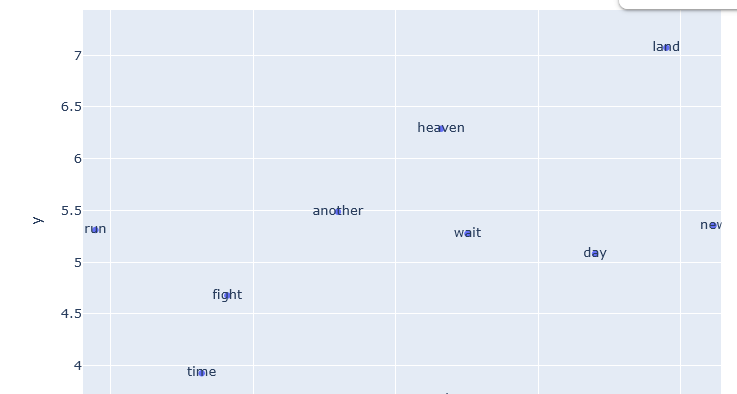

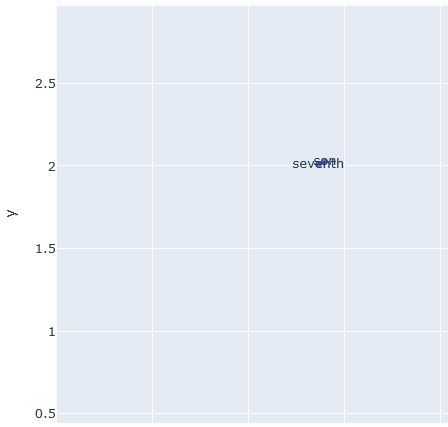

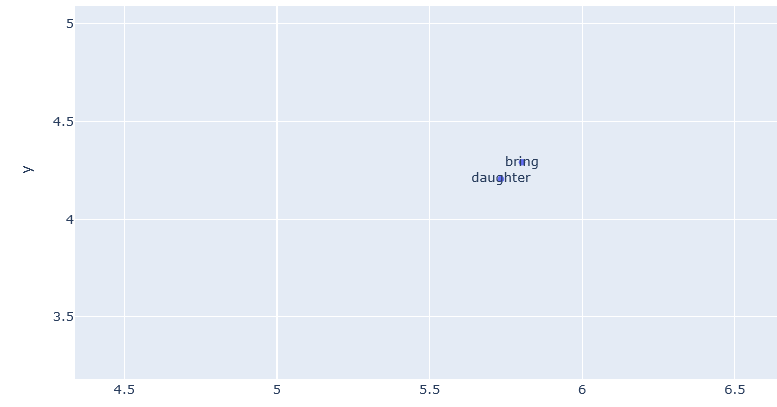